In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

# Load and prepare data
d = pd.read_csv('../data/clean_house_data.csv')
d = d.drop('Id', axis=1)
d.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier()
model.fit(X_train, y_train)

print("XGBoost and Scikit-Learn are compatible!")


XGBoost and Scikit-Learn are compatible!


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

#loading the data
d = pd.read_csv('../data/clean_house_data.csv')
d = d.drop('Id', axis=1)

#Encoding categorical variables
categorical_cols = ['Location','Condition','Garage']
label_encoders ={}

for col in categorical_cols:
    le =LabelEncoder()
    d[col] = le.fit_transform(d[col])
    label_encoders[col] = le #store encoders for later use

#Define features and target
X = d.drop('Price', axis=1)
y = d['Price']


#Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Train XGBoost Model
model = XGBRegressor(n_estimators=100, learning_rate =0.1, random_state=42)
model.fit(X_train_scaled, y_train)

#Predictions
y_pred = model.predict(X_test_scaled)

#Evaluated model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R-squared Score: {r2:.4f}')
print(f'Mean Squared Error: {mse:.2f}')








R-squared Score: -0.1790
Mean Squared Error: 86554951680.00


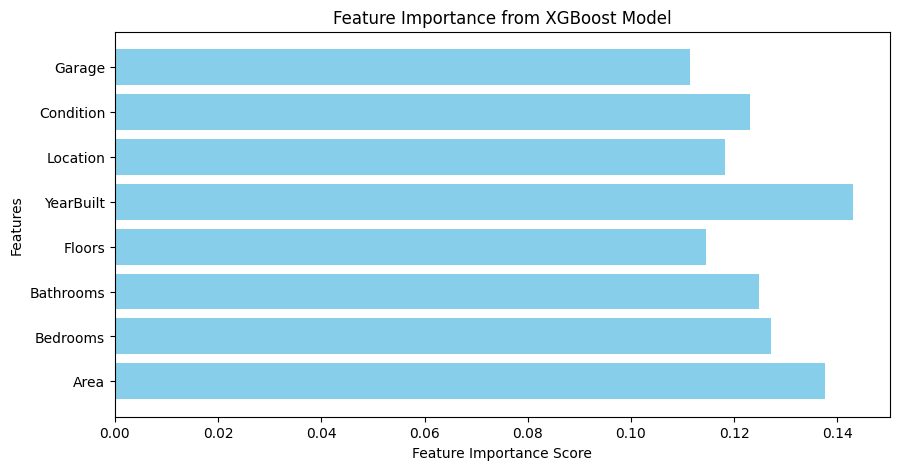

In [6]:
# Feature importance
import matplotlib.pyplot as plt

importance = model.feature_importances_

# Plotting feature importance
plt.figure(figsize = (10,5))
plt.barh(X.columns, importance, color ='skyblue')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance from XGBoost Model')
plt.show()

In [31]:
#loading the data
d = pd.read_csv('../data/clean_house_data.csv')
d = d.drop('Id', axis=1)

location_mapping = {
    'Urban': 0,
    'Rural': 1,
    'Downtown': 2,
    'Suburban': 3
}

condition_mapping = {
    'Poor': 0,
    'Good': 1,
    'Excellent': 2,
    'Fair': 3
}

garage_mapping ={
    'Yes': 0,
    'No':1
}

d['Location'] = d['Location'].map(location_mapping)
d['Condition'] = d['Condition'].map(condition_mapping)
d['Garage'] = d['Garage'].map(garage_mapping)

d.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,2,2,1,149919
1,4272,5,4,3,1958,2,2,1,424998
2,3592,2,2,3,1938,2,1,1,266746
3,966,4,2,2,1902,3,3,0,244020
4,4926,1,4,2,1975,2,3,0,636056


In [32]:
# Define features and target
X = d.drop('Price', axis=1)
y = d['Price']

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model (No Scaling)
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

model = XGBRegressor(n_estimators=100, learning_rate =0.1, random_state = 42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)

r2


-0.16295742988586426

In [33]:
from xgboost import XGBRegressor 
from sklearn.model_selection import GridSearchCV 
from sklearn.base import BaseEstimator, RegressorMixin

class XGBRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, **params):
        self.model = XGBRegressor(**params)
        self._estimator_type = "regressor"
        
    def fit(self, X, y):
        self.model.fit(X, y)
        return self
        
    def predict(self, X):
        return self.model.predict(X)
        
    def get_params(self, deep=True):
        return self.model.get_params(deep)
        
    def set_params(self, **params):
        self.model.set_params(**params)
        return self

# Define parameter grid 
param_grid = { 
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
} 

# Initialize model with wrapper - removed enable_categorical and added tree_method
xgb = XGBRegressorWrapper(
    random_state=42,
    objective='reg:squarederror',
    tree_method='hist'  # Using histogram-based tree method
)

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

# Fit the model
grid_search.fit(X, y)

# Best parameters 
print("Best Parameters: ", grid_search.best_params_) 
print("Best R-Square Score from Cross Validation:", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:  {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Best R-Square Score from Cross Validation: -0.0167830228805542


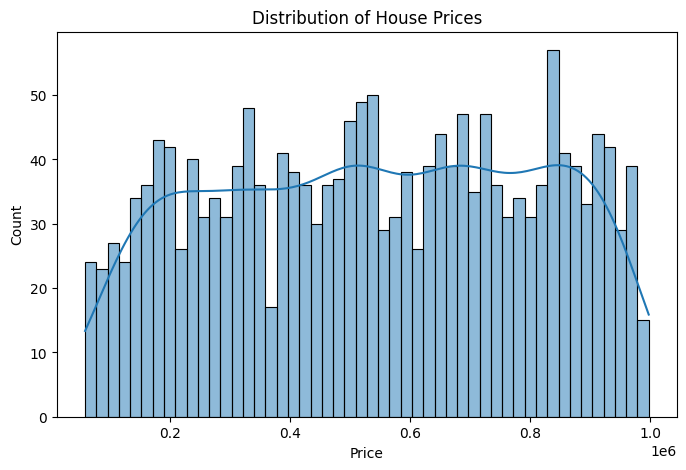

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check distribution of Price
plt.figure(figsize=(8,5))
sns.histplot(d['Price'], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.show()


In [34]:
import numpy as np

# Compute correlation matrix
corr_matrix = d.corr()

# Display correlations with Price
corr_with_price = corr_matrix['Price'].sort_values(ascending=False)
print(corr_with_price)


Price        1.000000
Floors       0.060998
Condition    0.049367
Location     0.044933
YearBuilt    0.016425
Area         0.008333
Bedrooms     0.007393
Garage       0.006486
Bathrooms   -0.005587
Name: Price, dtype: float64


In [47]:
#loading the data
d = pd.read_csv('../data/clean_house_data.csv')
d = d.drop('Id', axis=1)

location_mapping = {
    'Urban': 0,
    'Rural': 1,
    'Downtown': 2,
    'Suburban': 3
}

condition_mapping = {
    'Poor': 0,
    'Good': 1,
    'Excellent': 2,
    'Fair': 3
}

garage_mapping ={
    'Yes': 0,
    'No':1
}

d['Location'] = d['Location'].map(location_mapping)
d['Condition'] = d['Condition'].map(condition_mapping)
d['Garage'] = d['Garage'].map(garage_mapping)

d['Area_Bedrooms'] = d['Area']*d['Bedrooms']
d['Floors_Condition'] = d['Floors'] * d['Condition']
d['Garage_Condition'] = d['Garage'] * d['Condition']

from datetime import datetime
current_year = datetime.now().year
d['Age'] = current_year - d['YearBuilt']
d= d.drop(columns=['YearBuilt'])
d['Age_Squared'] = d['Age'] ** 2
d['Area_Squared'] = d['Area'] ** 2
d['Bathroom_Squared'] = d['Bathrooms']**2
d['Inverse_Age'] = 1/(d['Age'] + 0.1)
d['Log_Inverse_Age'] = np.log1p(d['Inverse_Age'])

In [45]:
corr_matrix = d.corr()
corr_with_price = corr_matrix['Price'].sort_values(ascending=False)
print(corr_with_price)

Price               1.000000
Floors_Condition    0.078234
Floors              0.060998
Condition           0.049367
Location            0.044933
Garage_Condition    0.030514
Inverse_Age         0.019350
Area_Bedrooms       0.018632
Log_Inverse_Age     0.018145
Area                0.008333
Bedrooms            0.007393
Garage              0.006486
Area_Squared        0.004314
Bathroom_Squared   -0.001134
Bathrooms          -0.005587
Age                -0.016425
Age_Squared        -0.020138
Name: Price, dtype: float64


In [48]:
drop_cols = [
    'Log_Inverse_Age',
    'Age',
    'Age_Squared',
    'Bathroom_Squared',
    'Bathrooms',
    'Area_Squared',
    'Area',
    'Bedrooms',
    'Garage'
]

d = d.drop(columns=drop_cols)

corr_matrix = d.corr()
corr_with_price = corr_matrix['Price'].sort_values(ascending=False)
print(corr_with_price)

Price               1.000000
Floors_Condition    0.078234
Floors              0.060998
Condition           0.049367
Location            0.044933
Garage_Condition    0.030514
Inverse_Age         0.019350
Area_Bedrooms       0.018632
Name: Price, dtype: float64


<Figure size 1000x500 with 0 Axes>

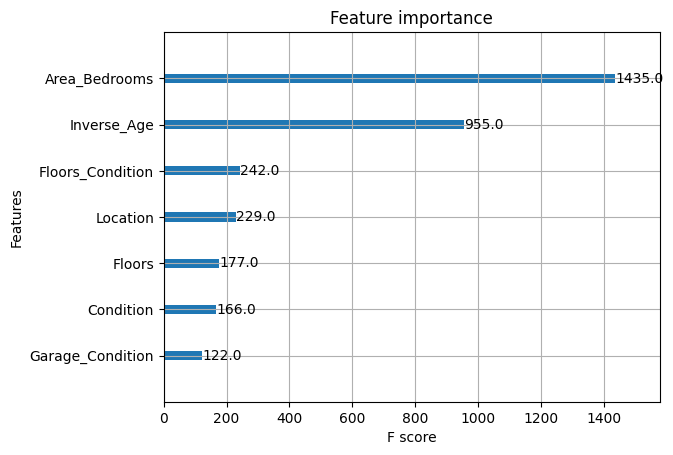

In [49]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Define features and target
X = d.drop(columns=['Price'])
y = d['Price']

# Train XGBoost Model
model = xgb.XGBRegressor(n_estimators=500, learning_rate = 0.01, max_depth=3, colsample_bytree=0.8, subsample=0.8, random_state=42)
model.fit(X,y)

# Plot feature importance
plt.figure(figsize=(10,5))
xgb.plot_importance(model, importance_type="weight")
plt.show()

In [50]:
# Drop Inverse_Age
X_without_age = X.drop(columns=['Inverse_Age'])

# Train & Evaluate Model
X_train, X_test, y_train, y_test = train_test_split(X_without_age, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2_without_inverse_age = r2_score(y_test, y_pred)
mse_without_inverse_age = mean_squared_error(y_test, y_pred)

print(f'XGBoost R² Score WITHOUT Inverse_Age: {r2_without_inverse_age:.4f}')
print(f'XGBoost Mean Squared Error WITHOUT Inverse_Age: {mse_without_inverse_age:.2f}')


XGBoost R² Score WITHOUT Inverse_Age: -0.0042
XGBoost Mean Squared Error WITHOUT Inverse_Age: 73722527744.00


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost Model
model.fit(X_train, y_train)

# Evaluate Model
y_pred = model.predict(X_test)
r2_with_inverse_age = r2_score(y_test, y_pred)
mse_with_inverse_age = mean_squared_error(y_test, y_pred)

print(f'XGBoost R² Score WITH Inverse_Age: {r2_with_inverse_age:.4f}')
print(f'XGBoost Mean Squared Error WITH Inverse_Age: {mse_with_inverse_age:.2f}')


XGBoost R² Score WITH Inverse_Age: -0.0100
XGBoost Mean Squared Error WITH Inverse_Age: 74148536320.00


In [60]:
#loading the data
d = pd.read_csv('../data/clean_house_data.csv')
d = d.drop('Id', axis=1)

location_mapping = {
    'Urban': 0,
    'Rural': 1,
    'Downtown': 2,
    'Suburban': 3
}

condition_mapping = {
    'Poor': 0,
    'Good': 1,
    'Excellent': 2,
    'Fair': 3
}

garage_mapping ={
    'Yes': 0,
    'No':1
}

d['Location'] = d['Location'].map(location_mapping)
d['Condition'] = d['Condition'].map(condition_mapping)
d['Garage'] = d['Garage'].map(garage_mapping)

d['Area_Bedrooms'] = d['Area']*d['Bedrooms']
d['Floors_Condition'] = d['Floors'] * d['Condition']
d['Garage_Condition'] = d['Garage'] * d['Condition']

from datetime import datetime
current_year = datetime.now().year
d['Age'] = current_year - d['YearBuilt']
d= d.drop(columns=['YearBuilt'])
d['Age_Squared'] = d['Age'] ** 2
d['Area_Squared'] = d['Area'] ** 2
d['Bathroom_Squared'] = d['Bathrooms']**2
d['Inverse_Age'] = 1/(d['Age'] + 0.1)
d['Log_Inverse_Age'] = np.log1p(d['Inverse_Age'])


drop_cols = [
    'Log_Inverse_Age',
    'Age',
    'Age_Squared',
    'Bathroom_Squared',
    'Bathrooms',
    'Area_Squared',
    'Area',
    'Bedrooms',
    
    'Garage'
]

d = d.drop(columns=drop_cols)

In [61]:
d.head()

,Floors,Location,Condition,Price,Area_Bedrooms,Floors_Condition,Garage_Condition,Inverse_Age
0,3,2,2,149919,6800,6,2,0.018149
1,3,2,2,424998,21360,6,2,0.014903
2,3,2,1,266746,7184,3,1,0.011481
3,2,3,3,244020,3864,6,0,0.008123
4,2,2,3,636056,4926,6,0,0.019960


In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Define features and target
X = d.drop(columns=['Price'])
y = d['Price']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate Model
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f'Random Forest R-Square: {r2_rf: .4f}')
print(f'Random Forest Mean Squared Error: {mse_rf: .2f}')


Random Forest R-Square: -0.0089
Random Forest Mean Squared Error:  74064836427.43
